# Data Preprocessing 02 - Processing Numerical Data

> **MLCourse · Data Science Foundations · 05_data_preprocessing**

Numeric columns look ready-to-use - they are numbers, after all. But hand a linear
model one feature in euros and another in years, or feed KNN a column of salaries
next to a column of ages, and the big-magnitude feature silently takes over. Add
skew and outliers - money data's signature - and naive inputs get worse.

This notebook covers the four numerical rituals: **scaling** (three scalers,
compared honestly), **skew fixes** (log1p, PowerTransformer), **binning**
(cut vs qcut) and **outliers** (detect, diagnose, treat). Every technique appears
twice: manual NumPy/pandas arithmetic first, then its scikit-learn twin using the
same fit/transform paradigm introduced in notebook 01.

### What you'll learn

- WHY scaling matters: distances, gradient descent and regularization fairness
- StandardScaler / MinMaxScaler / RobustScaler - formulas, manual + sklearn versions,
  and an outlier stress test that crowns a winner
- The shape-preservation insight: scaling never fixes skew
- Why `Normalizer` is NOT a scaler (row-wise trap)
- Detecting right-skew; fixing with `log1p` and `PowerTransformer(Yeo-Johnson)`
- Equal-width (`pd.cut`) vs equal-frequency (`pd.qcut`) binning
- Outlier detection (z-score, IQR fences) and four treatments compared on one series
- A reusable mini numeric-prep function applied to real Titanic fares

In [1]:
try:  # same effect as typing "%matplotlib inline" in Jupyter; safe as plain script
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    Normalizer,
    PowerTransformer,
)

np.random.seed(42)
sns.set_theme(style="whitegrid")

rng = np.random.default_rng(42)

### 1. WHY scale? Three concrete reasons

**What:** scaling rescales each *column* so features live on comparable ranges.
It changes nothing about what a value means - only its units.

**Why it matters - three mechanisms:**

1. **Distance-based algorithms** (KNN, k-means, SVM with RBF). Euclidean distance
   adds squared differences across features; the widest-range feature dominates.
2. **Gradient descent convergence.** Loss surfaces for unscaled features become
   long narrow valleys - tiny steps in one direction, huge in the other.
3. **Regularization fairness.** Ridge/lasso shrink coefficients equally; if one
   feature is measured in cents, its coefficient is artificially tiny and gets
   punished for the wrong reason.

In [2]:
alice = np.array([42.0, 52_000.0])   # [age, monthly income]
bob = np.array([45.0, 61_000.0])

raw_dist = np.linalg.norm(alice - bob)

age_scaled = (np.array([42.0, 45.0]) - 40.0) / 10.0          # pretend train stats
inc_scaled = (np.array([52_000.0, 61_000.0]) - 50_000.0) / 12_000.0
scaled_dist = np.linalg.norm(np.array([age_scaled[0] - age_scaled[1],
                                       inc_scaled[0] - inc_scaled[1]]))

print(f"raw distance     : {raw_dist:,.1f}   <- income contributes ~99.99% of it")
print(f"scaled distance  : {scaled_dist:.3f}  <- now age and income vote fairly")
print("\nwithout scaling, 'age' is invisible to any distance computation")

raw distance     : 9,000.0   <- income contributes ~99.99% of it
scaled distance  : 0.808  <- now age and income vote fairly

without scaling, 'age' is invisible to any distance computation


Our workhorse series for this notebook: `income`, deliberately lognormal - skewed
with heavy tails, i.e., how money always looks.

In [3]:
income = pd.Series(rng.lognormal(mean=10.8, sigma=0.65, size=800), name="monthly_income")
print(income.describe().round(0))
print(f"\nskew: {income.skew():.2f}   (right-skewed, like most monetary data)")

count       800.0
mean      59012.0
std       41481.0
min        7137.0
25%       30794.0
50%       48748.0
75%       73197.0
max      325791.0
Name: monthly_income, dtype: float64

skew: 2.14   (right-skewed, like most monetary data)


### 2. StandardScaler - the z-score default

**Formula:** z = (x - μ) / σ → every feature ends with mean 0 and standard
deviation 1. Units die; relative position survives ("2σ above typical").

**When:** your default for linear/logistic regression, PCA, neural nets, KNN -
anything that assumes roughly symmetric, unbounded inputs.

In [4]:
x = income.to_numpy()

z_manual = (x - x.mean()) / x.std(ddof=0)        # ddof=0 matches sklearn exactly!

scaler = StandardScaler()
z_sklearn = scaler.fit_transform(x.reshape(-1, 1)).ravel()

print("manual == sklearn:", np.allclose(z_manual, z_sklearn, atol=1e-9))
print(f"scaler learned mean_ : {scaler.mean_[0]:,.2f}")
print(f"scaler learned scale_: {scaler.scale_[0]:,.2f}  <- stored, reused on ANY future batch")

before_after = pd.DataFrame(
    {"raw": income.describe(), "standardized": pd.Series(z_sklearn).describe()}
).round(3)
before_after

manual == sklearn: True
scaler learned mean_ : 59,012.17
scaler learned scale_: 41,455.30  <- stored, reused on ANY future batch


,raw,standardized
count,800.000,800.000
mean,59012.169,-0.000
std,41481.229,1.001
min,7137.060,-1.251
25%,30793.895,-0.681
50%,48747.561,-0.248
75%,73196.705,0.342
max,325790.756,6.435


> ⚠️ **Common pitfall:** pandas' `.std()` uses `ddof=1` (sample std); sklearn and
> NumPy use `ddof=0`. Your manual z-scores will differ from `StandardScaler` in the
> ~15th decimal place until you pass `ddof=0`.

**Crucial intuition - scaling preserves shape.** Subtract-and-divide is affine:
it shifts and stretches axes but cannot bend a curve. A right-skewed salary stays
right-skewed after standardization. Proof by picture:

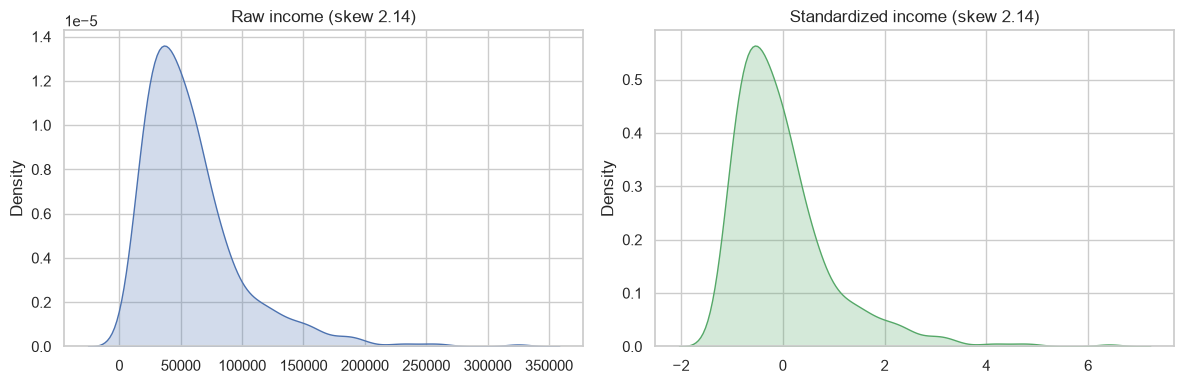

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(income, fill=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Raw income (skew {:.2f})".format(income.skew()))
sns.kdeplot(z_sklearn, fill=True, ax=axes[1], color="#55a868")
axes[1].set_title("Standardized income (skew {:.2f})".format(pd.Series(z_sklearn).skew()))
for ax in axes:
    ax.set_xlabel(None)
plt.tight_layout()
plt.show()

Same hump, same tail - only the axis numbers changed. Fixing shape needs §6.

### 3. MinMaxScaler - bounded, beautiful, fragile

**Formula:** x' = (x - min) / (max - min) → everything squeezed into [0, 1].

**When:** algorithms that want bounded inputs - pixel intensities for image nets,
some neural-network input layers, anywhere "0 to 1" has physical meaning.

**Weakness:** min and max ARE the outliers. One absurd value redefines the whole
denominator and crushes everyone else into a sliver near zero.

In [6]:
mm_manual = (x - x.min()) / (x.max() - x.min())
mm_sklearn = MinMaxScaler().fit_transform(x.reshape(-1, 1)).ravel()
print("manual == sklearn:", np.allclose(mm_manual, mm_sklearn, atol=1e-9))

# --- outlier sensitivity demo: append ONE huge value -------------------------
big_income = pd.concat([income, pd.Series([2_000_000.0])], ignore_index=True)
big_arr = big_income.to_numpy()

mm_big = MinMaxScaler().fit_transform(big_arr.reshape(-1, 1)).ravel()
st_big = StandardScaler().fit_transform(big_arr.reshape(-1, 1)).ravel()
rb_big = RobustScaler().fit_transform(big_arr.reshape(-1, 1)).ravel()

bulk = slice(0, len(big_income) - 1)                     # everyone except the whale
sensitivity = pd.DataFrame(
    {
        "bulk values span": [
            f"{mm_big[bulk].min():.4f} - {mm_big[bulk].max():.4f}",
            f"{st_big[bulk].min():+.2f} - {st_big[bulk].max():+.2f} sigma",
            f"{rb_big[bulk].min():+.2f} - {rb_big[bulk].max():+.2f} IQR-units",
        ]
    },
    index=["MinMax", "Standard", "Robust"],
)
sensitivity

manual == sklearn: True


,bulk values span
MinMax,0.0000 – 0.1599
Standard,-0.68 – +3.30 sigma
Robust,-0.98 – +6.52 IQR-units


Under MinMax, all 800 honest salaries now live inside a band ~0.001 wide - their
differences effectively erased. Standard loses resolution too; Robust barely blinks
(it never looked at min/max in the first place).

> 💡 **Pro tip:** If your feature has *known true bounds* (pixel = 0-255), divide by
> them directly instead of letting observed min/max set the scale - then a stray
> value can't redefine anything.

### 4. RobustScaler - statistics for messy rooms

**Formula:** x' = (x - median) / IQR, where IQR = Q75 - Q25. Median and IQR ignore
extreme tails by construction, so outliers can't kidnap the transformation.

**Showdown:** build a contaminated series (normal bulk + four wild points), run all
three scalers, and compare where the BULK lands.

In [7]:
clean_bulk = rng.normal(loc=50.0, scale=5.0, size=500)
contaminated = pd.Series(np.append(clean_bulk, [400.0, 380.0, -150.0, 420.0]),
                         name="sensor_reading")

scaled_views = {}
for name, obj in [("Standard", StandardScaler()),
                  ("MinMax", MinMaxScaler()),
                  ("Robust", RobustScaler())]:
    scaled_views[name] = obj.fit_transform(contaminated.to_numpy().reshape(-1, 1)).ravel()

stats_rows = []
for name, arr in scaled_views.items():
    q25, q75 = np.percentile(arr, [25, 75])
    stats_rows.append(
        {"scaler": name,
         "std_of_scaled": arr.std(),
         "iqr_of_scaled": q75 - q25,
         "where_95%_of_bulk_lives": f"[{np.percentile(arr[:500], 2.5):+.2f}, "
                                     f"{np.percentile(arr[:500], 97.5):+.2f}]"}
    )
pd.DataFrame(stats_rows).round(3)

,scaler,std_of_scaled,iqr_of_scaled,where_95%_of_bulk_lives
0,Standard,1.000,0.219,"[-0.42, +0.26]"
1,MinMax,0.051,0.011,"[+0.33, +0.37]"
2,Robust,4.563,1.000,"[-1.67, +1.44]"


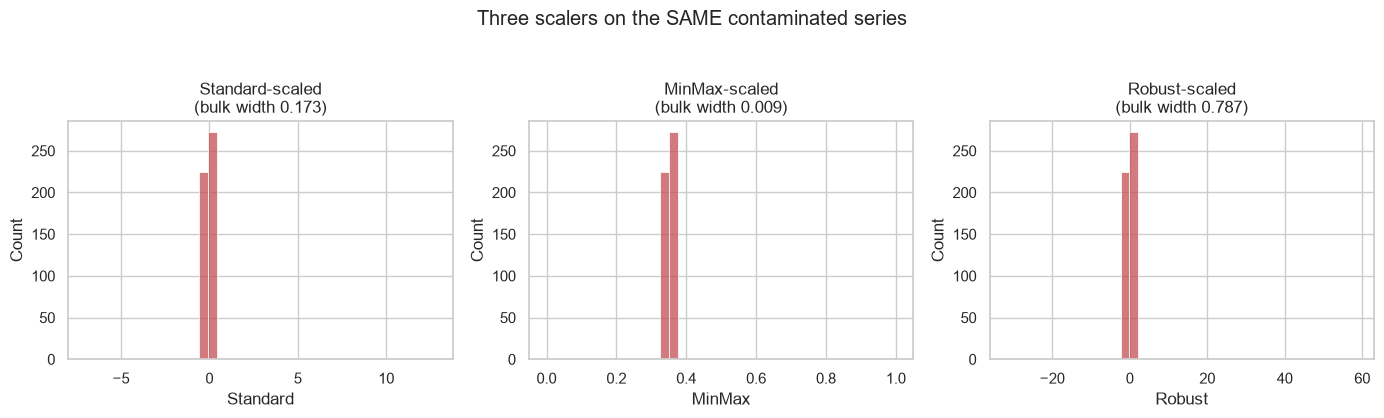

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (name, arr) in zip(axes, scaled_views.items()):
    sns.histplot(arr, bins=40, ax=ax, color="#c44e52")
    ax.set_title(f"{name}-scaled\n(bulk width {arr[:500].std():.3f})")
    ax.set_xlabel(name)
plt.suptitle("Three scalers on the SAME contaminated series", y=1.04)
plt.tight_layout()
plt.show()

Robust keeps the bulk spread wide and informative while the outliers simply stick
out at the edges; MinMax compresses the bulk into near-invisibility. On dirty,
money-flavored data, Robust is the safe default.

> ⚠️ **Common pitfall - `Normalizer` is not a scaler!**
>
> `Normalizer` rescales each **ROW** to unit length (L2 norm = 1): it makes
> `[3, 4]` into `[0.6, 0.8]`. Column scalers compare *features*; Normalizer compares
> *samples* by direction only. Its home turf is text vectors and similar
> direction-oriented data. Importing Normalizer when you meant StandardScaler is a
> classic silent bug.

In [9]:
X_rows = np.array([[3.0, 4.0],      # a 3-4-5 triangle
                   [1.0, 2.0],
                   [6.0, 2.0]])
normed = Normalizer().fit_transform(X_rows)   # fit is a no-op here; transform scales rows
print("unit norms per ROW:", np.linalg.norm(normed, axis=1).round(6))
print("columns were untouched as columns - each row just shrank onto the unit circle")

unit norms per ROW: [1. 1. 1.]
columns were untouched as columns - each row just shrank onto the unit circle


### 5. Skew fixes: bending the curve (scaling can't)

**WHAT:** right-skewed variables (salaries, fares, durations) have a long thin tail
of large values. Many models prefer symmetric-ish inputs; log-style transforms bend
that tail back toward the bulk.

**WHY detect first:** `skew()` gives a number (|skew| > ~1 = strong), histograms
give the story. Then choose the tool:

| Tool | Negatives allowed? | Character |
|---|---|---|
| `np.log1p` (= log(1+x)) | no (NaN below 0) | instant, interpretable, invert with expm1 |
| Box-Cox | strictly positive only | classic power family, λ fitted from data |
| Yeo-Johnson (`PowerTransformer`) | YES | generalizes Box-Cox; learns λ via fit/transform |

salary skew before : 2.14
after np.log1p     : 0.01


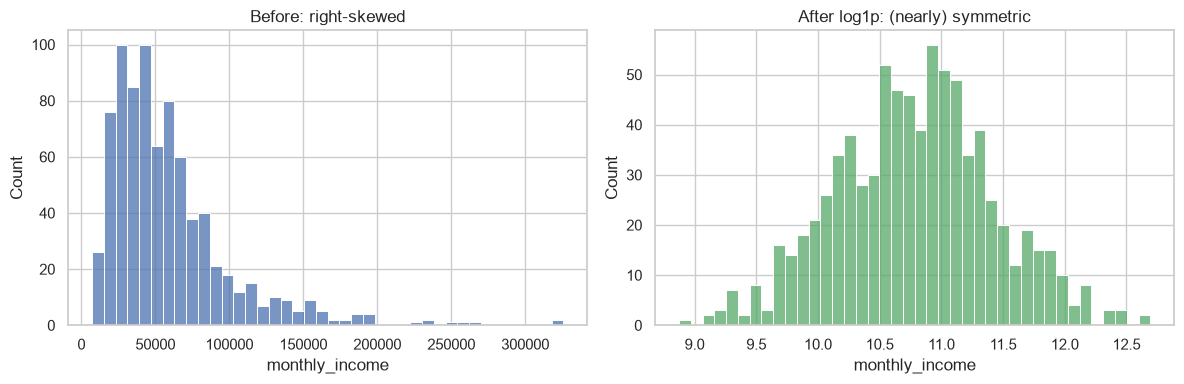

In [10]:
salary = income.copy()                       # reuse our skewed series
print(f"salary skew before : {salary.skew():.2f}")

log_salary = np.log1p(salary)
print(f"after np.log1p     : {log_salary.skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(salary, bins=40, ax=axes[0], color="#4c72b0")
axes[0].set_title("Before: right-skewed")
sns.histplot(log_salary, bins=40, ax=axes[1], color="#55a868")
axes[1].set_title("After log1p: (nearly) symmetric")
plt.tight_layout()
plt.show()

### Yeo-Johnson handles what log can't touch: negatives

Temperature anomalies dip below zero, so `log1p` would produce NaNs. Watch both
tools on a signed series:

In [11]:
temps = pd.Series(rng.normal(loc=5.0, scale=12.0, size=600), name="temp_anomaly")
negatives = int((temps < 0).sum())

with np.errstate(invalid="ignore"):          # silence the expected NaN warning
    log_attempt = np.log1p(temps)
log_nan_count = int(np.isnan(log_attempt).sum())

pt = PowerTransformer(method="yeo-johnson")  # fit/transform: lambda learned on train
yj_result = pt.fit_transform(temps.to_numpy().reshape(-1, 1)).ravel()

skew_table = pd.DataFrame(
    {
        "skew": [temps.skew(), np.nan, pd.Series(yj_result).skew()],
        "NaNs created": [0, log_nan_count, 0],
    },
    index=["raw", "log1p", "yeo-johnson"],
)
print(f"series has {negatives} negative values -> log1p poisons {log_nan_count} of them")
print(f"PowerTransformer learned lambda = {pt.lambdas_[0]:.3f}")
skew_table.round(3)

series has 216 negative values -> log1p poisons 202 of them
PowerTransformer learned lambda = 1.014


,skew,NaNs created
raw,-0.04,0
log1p,NaN,202
yeo-johnson,0.04,0


Rule of thumb: `log1p` for quick exploration of positive money-like data;
`PowerTransformer` when negatives exist or when λ should be *learned* inside a
pipeline rather than hard-coded.

> ⚠️ **Common pitfall:** Box-Cox raises on zero/negative inputs. If you must use it,
> shift the data first - or just reach for Yeo-Johnson and skip the ceremony.

### 6. Binning: cut vs qcut

**WHAT:** discretize a continuous variable into buckets.

- `pd.cut(s, bins=[edges])` → **equal WIDTH** bins; you choose human-readable edges.
- `pd.qcut(s, q=4)` → **equal FREQUENCY** bins; quantile edges guarantee balanced counts.

**WHY bother:** linear/logistic models gain cheap non-linearity - each bin gets its
own coefficient/step. Trees don't need this (and don't need scaling either: they
split per-feature thresholds), but linear models do benefit. Cost: within-bin detail
is discarded.

In [12]:
ages = pd.Series(rng.normal(loc=40, scale=13, size=1200)).clip(15, 85).round(0)

age_bands = pd.cut(
    ages,
    bins=[15, 25, 40, 55, 85],
    labels=["young", "adult", "middle", "senior"],   # labels arg -> readable output
)
print("pd.cut equal-width bands:")
print(age_bands.value_counts().sort_index())

fare_quartiles = pd.qcut(income, q=4, labels=["Q1_lowest", "Q2", "Q3", "Q4_highest"])
print("\npd.qcut equal-frequency quartiles:")
print(fare_quartiles.value_counts().sort_index())

pd.cut equal-width bands:
young     109
adult     464
middle    446
senior    142
Name: count, dtype: int64

pd.qcut equal-frequency quartiles:
monthly_income
Q1_lowest     200
Q2            200
Q3            200
Q4_highest    200
Name: count, dtype: int64


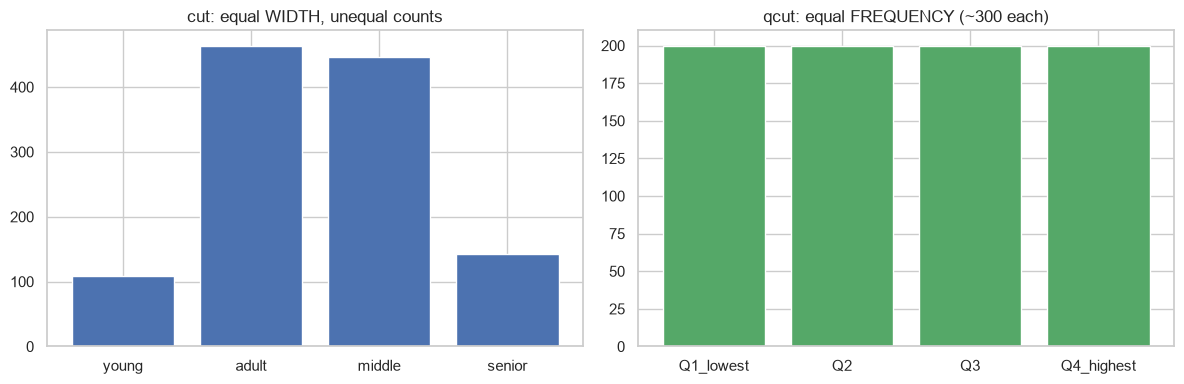

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(age_bands.value_counts().sort_index().index.astype(str),
            age_bands.value_counts().sort_index().values, color="#4c72b0")
axes[0].set_title("cut: equal WIDTH, unequal counts")
axes[1].bar(fare_quartiles.value_counts().sort_index().index.astype(str),
            fare_quartiles.value_counts().sort_index().values, color="#55a868")
axes[1].set_title("qcut: equal FREQUENCY (~300 each)")
plt.tight_layout()
plt.show()

On skewed data, equal-width bins starve the left side and gorge the right tail -
`qcut` is usually the fairer choice there. Remember that quantile edges are
*learned* boundaries: fit them on train, apply the same edges to test (another
fit/transform citizen).

> 💡 **Pro tip:** `qcut` fails with "Bin edges must be unique" on coarse/discrete
> data (duplicated quantiles). Add `duplicates="drop"` or round the series first.

### 7. Outliers: detect, diagnose, treat

**DETECT** with two complementary lenses:

- **z-score**: |z| > 3 flags points ≥ ~3σ from the mean. Simple, but assumes rough
  normality - and the outliers themselves inflate σ, hiding themselves (masking).
- **IQR fences**: flag outside `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` - exactly the whiskers
  of a boxplot. No normality assumption, robust to masking.

**DIAGNOSE before treating** - the cause decides the cure:
data-entry error → fix/remove; genuine heavy tail → transform or cap; genuine
extremes that ARE the phenomenon (fraud!) → leave alone, model robustly.

z-score flags   : 5 points [165.0, 172.0, -35.0, 180.0, 158.0]
IQR fences      : [69.1, 130.2]
IQR flags       : 10 points
(IQR sees more because outliers inflate the mean/std that z-score relies on)


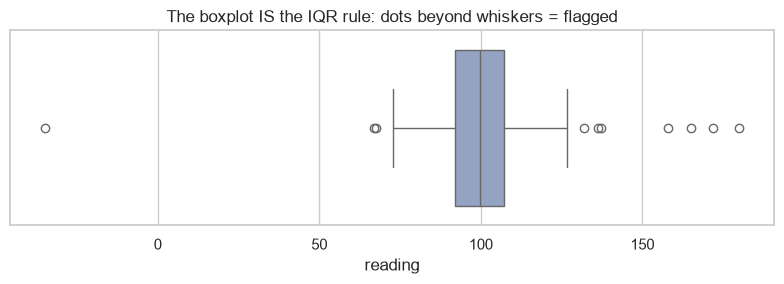

In [14]:
readings = pd.Series(rng.normal(loc=100, scale=12, size=300), name="reading")
outlier_positions = [17, 89, 150, 211, 263]
readings.iloc[outlier_positions] = [165.0, 172.0, -35.0, 180.0, 158.0]

z_scores = (readings - readings.mean()) / readings.std()
flagged_z = readings[np.abs(z_scores) > 3]

q1, q3 = readings.quantile([0.25, 0.75])
iqr = q3 - q1
lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flagged_iqr = readings[(readings < lo_fence) | (readings > hi_fence)]

print(f"z-score flags   : {len(flagged_z)} points {list(flagged_z.round(0))}")
print(f"IQR fences      : [{lo_fence:.1f}, {hi_fence:.1f}]")
print(f"IQR flags       : {len(flagged_iqr)} points")
print("(IQR sees more because outliers inflate the mean/std that z-score relies on)")

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=readings, ax=ax, color="#8da0cb")
ax.set_title("The boxplot IS the IQR rule: dots beyond whiskers = flagged")
plt.tight_layout()
plt.show()

### Treatment showdown on the same series

Four policies, one scoreboard:

In [15]:
treated = {
    "original (leave)": readings.copy(),
    "remove": readings[(readings >= lo_fence) & (readings <= hi_fence)],
    "cap / winsorize": readings.clip(lo_fence, hi_fence),
    "transform": np.log1p(readings - lo_fence + 1),   # shift so min >= 0, then log
}

rows = []
for name, s in treated.items():
    rows.append({
        "policy": name,
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "skew": s.skew(),
        "extreme_max": s.max(),
    })
pd.DataFrame(rows).set_index("policy").round(2)

D:\projects\python\MLCourse\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,n,mean,std,skew,extreme_max
policy,,,,,
original (leave),300,100.02,15.75,-0.96,180.00
remove,290,99.40,10.33,-0.04,126.81
cap / winsorize,300,99.82,11.59,0.12,130.15
transform,300,3.42,0.47,-2.74,4.73


Read the scoreboard: **leave** preserves truth including tails; **remove** shrinks n
and understates variability; **cap** keeps every row but pins tails at the fences
(winsorizing - great default for dirty business data); **transform** tames skew AND
extremes smoothly but changes interpretation (units become log-ish).

### 8. Putting it together: a mini numeric-prep function

**What:** bundle the chapter's decisions into one reusable transformer-style
function: de-skew if badly skewed, then robust-scale. Apply it to Titanic fares.

**Why these choices:** fares are money → skew almost guaranteed → median/IQR family
throughout. In production you would express this as a sklearn pipeline (notebook 06);
the manual version shows the seams.

In [16]:
def make_synthetic_fares(n=800):
    r = np.random.default_rng(7)
    pclass = r.choice([1, 2, 3], size=n, p=[0.25, 0.22, 0.53])
    mu = np.where(pclass == 1, np.log(85.0), np.where(pclass == 2, np.log(22.0), np.log(9.5)))
    return pd.DataFrame({"pclass": pclass, "fare": r.lognormal(mu, 0.6).round(2)})


try:
    titanic_fare = sns.load_dataset("titanic")[["pclass", "fare"]].dropna().reset_index(drop=True)
    source = "seaborn titanic"
except Exception:
    titanic_fare = make_synthetic_fares()
    source = "synthetic titanic-like"

SKEW_THRESHOLD = 1.0


def prep_numeric(s, skew_threshold=SKEW_THRESHOLD):
    """De-skew (if needed) then robust-scale. Returns a Series."""
    s = s.astype(float)
    if abs(s.skew()) > skew_threshold:
        s = np.log1p(s)                      # step 1: bend the tail
    scaled = RobustScaler().fit_transform(s.to_numpy().reshape(-1, 1)).ravel()
    return pd.Series(scaled, index=s.index, name=f"{s.name}_prepped")


raw_fare = titanic_fare["fare"]
prepped_fare = prep_numeric(raw_fare)

report = pd.DataFrame(
    {"raw fare": [raw_fare.mean(), raw_fare.std(), raw_fare.skew()],
     "prepped fare": [prepped_fare.mean(), prepped_fare.std(), prepped_fare.skew()]},
    index=["mean", "std", "skew"],
).round(3)
print(f"data source: {source}")
report

data source: seaborn titanic


,raw fare,prepped fare
mean,32.204,0.175
std,49.693,0.758
skew,4.787,0.395


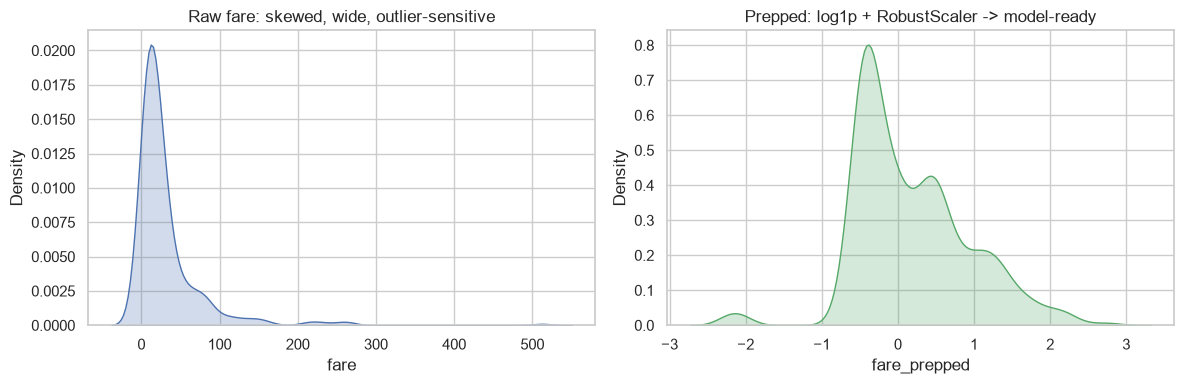

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(raw_fare, fill=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Raw fare: skewed, wide, outlier-sensitive")
sns.kdeplot(prepped_fare, fill=True, ax=axes[1], color="#55a868")
axes[1].set_title("Prepped: log1p + RobustScaler -> model-ready")
plt.tight_layout()
plt.show()

> ⚠️ **Common pitfall:** In a real project, `prep_numeric`'s thresholds, medians and
> IQRs must be learned on TRAIN only. The function above fits on whatever it is
> handed - fine for a demo, leakage in production. Notebook 06 wraps it safely.

### Summary & key takeaways

- Scale for the algorithm's sake: distances (KNN), optimization (gradient descent),
  fairness (regularization). Trees don't care.
- **StandardScaler** = default; **MinMax** = bounded inputs but hostage to max();
  **Robust** = median/IQR, wins on contaminated data.
- Scaling shifts and stretches - it NEVER reshapes. De-skew first (`log1p` /
  `PowerTransformer`), scale second.
- `Normalizer` works on rows, not columns - different beast entirely.
- `pd.cut` for readable equal-width bands; `pd.qcut` for balanced bins on skew.
- Outliers: detect with BOTH z-score and IQR fences, diagnose the cause, then leave
  / remove / cap / transform accordingly.
- Ship-ready recipe: `if skew > 1: log1p` → `RobustScaler`, fitted on train.

Next up: `03_categorical_data.nb.py` - turning words into honest numbers.